In [1]:
# KERAS FUNCTIONAL API USING MNIST

In [1]:
import pandas as pd
import numpy as np

np.random.seed(1212)

import keras
from keras.models import Model
from keras.layers import *
from keras import optimizers

In [ ]:
# np.random.seed(1212) 
→ Sets a fixed random starting point so results stay the same every time you run the code.
# import keras 
→ Loads the Keras library used to build neural networks.
# from keras.models import Model 
→ Imports the Model 
# from keras.layers import * 
→ Imports all layer types (like Dense, Conv, etc.) to build the network.
# from keras import optimizers 
→ Imports optimization methods (like Adam, SGD) used to train the model efficiently.

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_features = df_train.iloc[:, 1:785]
df_label = df_train.iloc[:, 0]

In [ ]:
df_train 
→ This is your main dataset that contains both input features or variables and labels or correct output used for training a model.


# df_features = 
A new DataFrame that contains only the input features from df_train excluding the first column 

# df_train.iloc[:, 1:785]    
→ Selects all rows and columns from index 1 to 784  as input variables 
    

df_label = df_train.iloc[:, 0] 
→ Selects all rows of the first column as the label or correct output

In [6]:
X_test = df_test.iloc[:, 0:784]
X_test

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# df_test 
→ your test dataset 
# .iloc
→ selects data by position 
# :,
→ take all rows
# 0:784
→ take columns from index 0 up to 783
# X_test = ... 
→ store this data in a new variable called X_test

In [7]:
print(X_test.shape)

(28000, 784)


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_cv, y_train, y_cv = train_test_split(df_features, df_label, test_size = 0.2,random_state = 1212)
                                               
                                                

In [ ]:
# from scikit-learn.model_selection import train_test_split 
→ Import a function that splits data into training and testing parts.

X_train, X_cv, y_train, y_cv = 
→ Create four variables to store split data (features and labels for training and validation).

# train_test_split(...) 
→ Call the function to divide your dataset into smaller parts.

# df_features 
→ " Input features or independent variables"  used for prediction

# df_label 
→ Target labels that you want to predict.

# test_size = 0.2 
→ Keep 20% of data for validation/testing and 80% for training.

# random_state = 1212 
→ Fix the random split so you get the same result every time you run the code.


In [9]:
X_train = X_train.to_numpy().reshape(33600, 784)
X_cv = X_cv.to_numpy().reshape(8400, 784)

In [ ]:
# X_train.to_numpy() 
→ converts the training data  into a NumPy array.
# .reshape(33600, 784) 
→ reshapes it into 33,600 samples with 784 features each 
# X_cv.to_numpy() 
→ converts the cross-validation dataset into a NumPy array.
# .reshape(8400, 784) 
→ reshapes it into 8,400 samples with 784 features each (

In [ ]:
In  MNIST data We reshape training dataset X_train into (33600, 784) and testing dataset X_cv (8400, 784) so each image  
becomes a flat input vector


The original dataset has 28000 rows (images) and 784 columns (pixels), 
but using 33600 and 8400 rows means you likely split  the data into training and testing sets

We split data into training and test sets to check if the model learns general patterns instead of just memorizing 
the training data to avoid overfitting

Rule to choose rows for training and tewstinf datasets : commonly 70–90% for training and 10–30% for testing depending 
on dataset size.

so  for training    70 % of 28,000 = 19,600 rows    an  for testing    30% of 28000 = 8400 rows

but actual rows used during reshape in training datasets is 33600 
It means 33600-19600 = 14000 rows were increased in your training data
It means Each original image was transformed to create new images to increase training data by ~50%
This is called data augmentation


In [10]:
X_test = X_test.to_numpy().reshape(28000, 784)
X_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(28000, 784))

In [ ]:
# X_test.to_numpy() 
→ Converts X_test  into a NumPy array for numerical processing.
# .reshape(28000, 784) 
→ Changes the array shape into 28,000 samples with 784 features
# X_test = ... 
→ Stores the transformed NumPy array

In [11]:
print((min(X_train[1]), max(X_train[1])))

(np.int64(0), np.int64(255))


In [ ]:
# X_train[1] 
→ selects the second row/sample from the training dataset

# min(X_train[1]) 
→ finds the smallest value in that selected row.

# max(X_train[1])
→ finds the largest value in that selected row.



In [ ]:
Meaning (short & clear):
0 → minimum value in X_train[1]
255 → maximum value in X_train[1]

Range 0–255 usually means:
It is image pixel data
0 = black
255 = white

In [12]:
# Feature Normalization
X_train = X_train.astype('float32'); 
X_cv= X_cv.astype('float32'); 
X_test = X_test.astype('float32')

X_train /= 255; 
X_cv /= 255; 
X_test /= 255

In [ ]:
# X_train = X_train.astype('float32') 
→ converts training data values to 32-bit floating-point for faster computation and better precision during model training.
# X_cv = X_cv.astype('float32') 
→ converts cross-validation data to float32 to ensure consistency with training data.
# X_test = X_test.astype('float32') 
→ converts test data to float32 so predictions work correctly with the model.

    
# X_train /= 255 
→ normalizes training data by scaling pixel values from range [0, 255] to [0, 1].
# X_cv /= 255
→ normalizes validation data by scaling pixel values from range [0, 255] to [0, 1] 
# X_test /= 255 
→ normalizes test data by scaling pixel values from range [0, 255] to [0, 1] 

In [13]:
num_digits = 10
y_train = keras.utils.to_categorical(y_train, num_digits)
y_cv = keras.utils.to_categorical(y_cv, num_digits)

In [ ]:
num_digits = 10 
# sets total number of classes (digits 0–9).
y_train = keras.utils.to_categorical(y_train, num_digits) 
# converts training labels or correct outputs obtained during checking of model to learn patterns from the data. 
# into one-hot encoded vectors of length 10.
y_cv = keras.utils.to_categorical(y_cv, num_digits) 
# converts cross-validation labels or correct outputs obtained during checking of model into one-hot 
# encoded vectors of length 10.

In [ ]:
# a label is the correct answer/output for a given input.
# Training label → correct output during learning
# Validation label → correct output during checking

In [14]:
print(y_train[0]) 
print(y_train[3]) 

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [ ]:
It prints the correct output of the 1st and 4th training samples.

In [15]:
# Input Parameters
n_input = 784 
n_hidden_1 = 300
n_hidden_2 = 100
n_hidden_3 = 100
n_hidden_4 = 200
num_digits = 10

In [ ]:
n_input = 784
# input layer has 784 neurons, 

n_hidden_1 = 300
# First hidden layer has 300 neurons.

n_hidden_2 = 100
# Second hidden layer has 100 neurons.

n_hidden_3 = 100
# Third hidden layer has 100 neurons.

n_hidden_4 = 200
# Fourth hidden layer has 200 neurons.


num_digits = 10
# Output layer has 10 classes.
# Used for digits 0 to 9 classification.



In [16]:
Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
# Inp = Input(shape=(784,))
Shows Input layer
Takes 784 features (e.g., 28×28 image flattened into a vector)

# x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
Shows First hidden layer
n_hidden_1 = number of neurons in 1st hidden layer
ReLU → activation function
Takes input from Inp from previous layer

# x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
Shows Second hidden layer
n_hidden_2 = number of neurons in 2nd hidden layer
ReLU → activation function
Takes input from x from previous layer

Takes output from previous layer (x)

# x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)

Shows third hidden layer
n_hidden_3 = number of neurons in 3rd hidden layer
ReLU → activation function
Takes input from x from previous layer

# x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
Shows 4rth hidden layer
n_hidden_4 = number of neurons in 4rth hidden layer
ReLU → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)
Shows output  layer
num_digits = number of classes OR number of  digits 0–9 in MNIST DATASET
Softmax → activation function converts outputs into probabilities
Takes input from x from previous layer

In [ ]:
Simple overall meaning:

👉 You are building a deep neural network with:

1 input layer (784 features)
4 hidden layers (ReLU activation)
1 output layer (Softmax for classification)

In [17]:
model = Model(Inp, output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,910 (1.14 MB)

 Trainable params: 297,910 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model
→ Variable name used to store the neural network model.

# Model() 
→ Keras function used to create a deep learning model using Functional API.

# Model(Inp, output) 
→ Creates a complete model from input layer to output layer.

# model.summary() 
→ Shows model architecture: layers, output shapes, parameters.

In [18]:
# Insert Hyperparameters
training_epochs = 20
batch_size = 100
sgd = optimizers.SGD(learning_rate = 0.1)

In [ ]:
learning_rate = 0.1
# learning_rate = Step size used to update model weights during training.


training_epochs = 20
# training_epochs = Number of times whole dataset is trained.


batch_size = 100
# batch_size = Number of samples used in one training step.

sgd = optimizers.SGD(learning_rate = learning_rate)
# sgd = Variable storing optimizer object.

optimizers.SGD  
# Creates Stochastic Gradient Descent optimizer.



In [19]:
# We rely on the plain vanilla Stochastic Gradient Descent as our optimizing methodology

model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

training_result1 = model.fit(X_train, y_train,
                     batch_size = batch_size,
                     epochs = training_epochs,
                     verbose = 2,
                     validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 - 5s - 14ms/step - accuracy: 0.5041 - loss: 1.8053 - val_accuracy: 0.7717 - val_loss: 0.9622
Epoch 2/20
336/336 - 5s - 14ms/step - accuracy: 0.8236 - loss: 0.6360 - val_accuracy: 0.8676 - val_loss: 0.4699
Epoch 3/20
336/336 - 4s - 11ms/step - accuracy: 0.8841 - loss: 0.4099 - val_accuracy: 0.8944 - val_loss: 0.3660
Epoch 4/20
336/336 - 5s - 14ms/step - accuracy: 0.9027 - loss: 0.3372 - val_accuracy: 0.9108 - val_loss: 0.3122
Epoch 5/20
336/336 - 2s - 7ms/step - accuracy: 0.9137 - loss: 0.2966 - val_accuracy: 0.9170 - val_loss: 0.2920
Epoch 6/20
336/336 - 3s - 8ms/step - accuracy: 0.9223 - loss: 0.2691 - val_accuracy: 0.9276 - val_loss: 0.2646
Epoch 7/20
336/336 - 5s - 16ms/step - accuracy: 0.9282 - loss: 0.2470 - val_accuracy: 0.9304 - val_loss: 0.2454
Epoch 8/20
336/336 - 5s - 15ms/step - accuracy: 0.9335 - loss: 0.2278 - val_accuracy: 0.9327 - val_loss: 0.2351
Epoch 9/20
336/336 - 13s - 38ms/step - accuracy: 0.9378 - loss: 0.2116 - val_accuracy: 0.9374 - val_loss: 

In [ ]:
# 1. model.compile(...)
→ Prepares the model for training (defines how it learns).

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='sgd'
→ setting an stochastic gradient descent algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.

In [ ]:
# training_result1
→ Variable that stores training results.

# model
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of full passes through training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

In [20]:
Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
# Inp = Input(shape=(784,))
Shows Input layer
Takes 784 features (e.g., 28×28 image flattened into a vector)

# x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
Shows First hidden layer
n_hidden_1 = number of neurons in 1st hidden layer
ReLU → activation function
Takes input from Inp from previous layer

# x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
Shows Second hidden layer
n_hidden_2 = number of neurons in 2nd hidden layer
ReLU → activation function
Takes input from x from previous layer

Takes output from previous layer (x)

# x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)

Shows third hidden layer
n_hidden_3 = number of neurons in 3rd hidden layer
ReLU → activation function
Takes input from x from previous layer

# x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
Shows 4rth hidden layer
n_hidden_4 = number of neurons in 4rth hidden layer
ReLU → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)
Shows output  layer
num_digits = number of classes OR number of  digits 0–9 in MNIST DATASET
Softmax → activation function converts outputs into probabilities
Takes input from x from previous layer

In [21]:
adam = keras.optimizers.Adam(learning_rate = learning_rate)
model2 = Model(Inp, output)

model2.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
# 1. adam = keras.optimizers.Adam(learning_rate = learning_rate)
This line creates an optimizer object using Keras.

# learning_rate = learning_rate
Controls how big each update step is while training


In [ ]:
# 1. model2.compile(...)
→ Prepares the model for training (defines how it learns).

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='adam'
→ setting an adam algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.

In [22]:
training_result2 = model2.fit(X_train, y_train,
                     batch_size = batch_size,
                     epochs = training_epochs,
                     verbose = 2,
                     validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 - 10s - 29ms/step - accuracy: 0.9035 - loss: 0.3327 - val_accuracy: 0.9567 - val_loss: 0.1486
Epoch 2/20
336/336 - 5s - 16ms/step - accuracy: 0.9614 - loss: 0.1230 - val_accuracy: 0.9630 - val_loss: 0.1245
Epoch 3/20
336/336 - 7s - 21ms/step - accuracy: 0.9747 - loss: 0.0821 - val_accuracy: 0.9706 - val_loss: 0.1042
Epoch 4/20
336/336 - 11s - 32ms/step - accuracy: 0.9800 - loss: 0.0628 - val_accuracy: 0.9736 - val_loss: 0.0889
Epoch 5/20
336/336 - 5s - 16ms/step - accuracy: 0.9858 - loss: 0.0452 - val_accuracy: 0.9721 - val_loss: 0.1045
Epoch 6/20
336/336 - 6s - 17ms/step - accuracy: 0.9879 - loss: 0.0375 - val_accuracy: 0.9696 - val_loss: 0.1147
Epoch 7/20
336/336 - 9s - 27ms/step - accuracy: 0.9899 - loss: 0.0298 - val_accuracy: 0.9762 - val_loss: 0.0918
Epoch 8/20
336/336 - 6s - 18ms/step - accuracy: 0.9912 - loss: 0.0253 - val_accuracy: 0.9758 - val_loss: 0.0903
Epoch 9/20
336/336 - 5s - 16ms/step - accuracy: 0.9918 - loss: 0.0269 - val_accuracy: 0.9694 - val_los

In [ ]:
# training_result2
→ Variable that stores training results.

# model2
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of full passes through training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

model2
→ Your neural network model
.fit(...)
→ Starts training the model

In [23]:
# Model 2A

Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
# Inp = Input(shape=(784,))
Shows Input layer
Takes 784 features (e.g., 28×28 image flattened into a vector)

# x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
Shows First hidden layer
n_hidden_1 = number of neurons in 1st hidden layer
ReLU → activation function
Takes input from Inp from previous layer

# x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
Shows Second hidden layer
n_hidden_2 = number of neurons in 2nd hidden layer
ReLU → activation function
Takes input from x from previous layer

Takes output from previous layer (x)

# x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)

Shows third hidden layer
n_hidden_3 = number of neurons in 3rd hidden layer
ReLU → activation function
Takes input from x from previous layer

# x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
Shows 4rth hidden layer
n_hidden_4 = number of neurons in 4rth hidden layer
ReLU → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)
Shows output  layer
num_digits = number of classes OR number of  digits 0–9 in MNIST DATASET
Softmax → activation function converts outputs into probabilities
Takes input from x from previous layer

In [24]:
adam = keras.optimizers.Adam(learning_rate =  0.01)
model2a = Model(Inp, output)

In [ ]:
# 1. learning_rate = 0.01
→ Sets how big a step the model takes while updating weights during training.

# 2. adam = keras.optimizers.Adam(learning_rate = learning_rate)
→ Creates an Adam optimizer that automatically adjusts learning speed for faster and stable training.

# 3. model2a = Model(Inp, output)
→ Builds a neural network model by connecting input layer (Inp) to final output layer (output).

In [25]:
model2a.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])



In [ ]:
# 1. model2a.compile(...)
→ Prepares the model for training (defines how it learns).

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='adam'
→ setting an adam algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.

In [26]:
training_result2a = model2a.fit(X_train, y_train,
                        batch_size = batch_size,
                        epochs = training_epochs,
                        verbose = 2,
                        validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 - 9s - 27ms/step - accuracy: 0.8930 - loss: 0.3527 - val_accuracy: 0.9515 - val_loss: 0.1630
Epoch 2/20
336/336 - 8s - 24ms/step - accuracy: 0.9615 - loss: 0.1256 - val_accuracy: 0.9633 - val_loss: 0.1169
Epoch 3/20
336/336 - 4s - 11ms/step - accuracy: 0.9735 - loss: 0.0851 - val_accuracy: 0.9702 - val_loss: 0.0951
Epoch 4/20
336/336 - 4s - 12ms/step - accuracy: 0.9805 - loss: 0.0605 - val_accuracy: 0.9696 - val_loss: 0.1057
Epoch 5/20
336/336 - 5s - 16ms/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9726 - val_loss: 0.1003
Epoch 6/20
336/336 - 5s - 14ms/step - accuracy: 0.9888 - loss: 0.0358 - val_accuracy: 0.9689 - val_loss: 0.1077
Epoch 7/20
336/336 - 6s - 17ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9680 - val_loss: 0.1231
Epoch 8/20
336/336 - 6s - 19ms/step - accuracy: 0.9919 - loss: 0.0255 - val_accuracy: 0.9712 - val_loss: 0.1161
Epoch 9/20
336/336 - 12s - 35ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9761 - val_loss

In [ ]:
# training_result2a 
→ Variable that stores training results.

# model2a 
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of full passes through training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

# TRAINING MODEL BY CHANGING LEARNING RATE TO 0.5

In [27]:
# Model 2b

Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
# Inp = Input(shape=(784,))
Shows Input layer
Takes 784 features (e.g., 28×28 image flattened into a vector)

# x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
Shows First hidden layer
n_hidden_1 = number of neurons in 1st hidden layer
relu → activation function
Takes input from Inp from previous layer

# x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
Shows Second hidden layer
n_hidden_2 = number of neurons in 2nd hidden layer
relu → activation function
Takes input from x from previous layer


# x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)

Shows third hidden layer
n_hidden_3 = number of neurons in 3rd hidden layer
ReLU → activation function
Takes input from x from previous layer

# x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
Shows 4rth hidden layer
n_hidden_4 = number of neurons in 4rth hidden layer
relu → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)
Shows output  layer
num_digits = number of classes OR number of  digits 0–9 in MNIST DATASET
Softmax → activation function converts outputs into probabilities
Takes input from x from previous layer

In [30]:
adam = keras.optimizers.Adam(learning_rate =  0.5)
model2b = Model(Inp, output)


In [ ]:
# 1. learning_rate = 0.5
→ Sets how big a step the model takes while updating weights during training.

# 2. adam = keras.optimizers.Adam(learning_rate = learning_rate)
→ Creates an Adam optimizer that automatically adjusts learning speed for faster and stable training.

# 3. model2b = Model(Inp, output)
→ Builds a neural network model by connecting input layer (Inp) to final output layer (output).

In [31]:
model2b.compile(loss='categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

In [ ]:
# 1. model2b.compile(...)
→ Prepares the model for training (defines how it learns).

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='adam'
→ setting an adam algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.



In [32]:
training_result2b = model2b.fit(X_train, y_train,
                        batch_size = batch_size,
                        epochs = training_epochs,
                        validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8985 - loss: 0.3437 - val_accuracy: 0.9520 - val_loss: 0.1534
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9623 - loss: 0.1224 - val_accuracy: 0.9585 - val_loss: 0.1464
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9732 - loss: 0.0858 - val_accuracy: 0.9654 - val_loss: 0.1226
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9823 - loss: 0.0562 - val_accuracy: 0.9706 - val_loss: 0.1108
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9704 - val_loss: 0.1134
Epoch 6/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9873 - loss: 0.0384 - val_accuracy: 0.9706 - val_loss: 0.1118
Epoch 7/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9901 - loss: 0.0299 - val_accuracy: 0.9729 - val_loss: 0.1127
Epoch 8/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accu

In [ ]:
# training_result2b 
→ Variable that stores training results.

# model2b 
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of full passes through training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

# TRAINING MODEL USING 5 HIDDEN LAYER 

In [33]:
# Input Parameters
n_input = 784 # number of features
n_hidden_1 = 300
n_hidden_2 = 100
n_hidden_3 = 100
n_hidden_4 = 100
n_hidden_5 = 200
num_digits = 10

In [ ]:
n_input = 784
# input layer has 784 neurons,

n_hidden_1 = 300
# First hidden layer has 300 neurons.

n_hidden_2 = 100
# Second hidden layer has 100 neurons.

n_hidden_3 = 100
# Third hidden layer has 100 neurons.

n_hidden_4 = 100
# Fourth hidden layer has 100 neurons.

n_hidden_5 = 200
# Fifth hidden layer has 200 neurons.

num_digits = 10
# Output layer has 10 classes.
# Used for digits 0 to 9 classification.

Overall Meaning:

# This code defines the network structure of a deep neural network with 1 input layer, 5 hidden layers, and 1 output layer.

In [34]:
Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
x = Dense(n_hidden_5, activation='relu', name = "Hidden_Layer_5")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
# Inp = Input(shape=(784,))
Shows Input layer
Takes 784 features (e.g., 28×28 image flattened into a vector)

# x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
Shows First hidden layer
n_hidden_1 = number of neurons in 1st hidden layer
relu → activation function
Takes input from Inp from previous layer

# x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
Shows Second hidden layer
n_hidden_2 = number of neurons in 2nd hidden layer
relu → activation function
Takes input from x from previous layer


# x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)

Shows third hidden layer
n_hidden_3 = number of neurons in 3rd hidden layer
relu → activation function
Takes input from x from previous layer

# x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
Shows 4rth hidden layer
n_hidden_4 = number of neurons in 4rth hidden layer
relu → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# x = Dense(n_hidden_5, activation='relu', name = "Hidden_Layer_5")(x)
Shows 5th hidden layer
n_hidden_5 = number of neurons in 5th hidden layer
relu → activation function
Takes input from x from previous layer
Deepens the network for more learning capacity

# output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)
Shows output layer
num_digits = number of classes OR number of  digits 0–9 in MNIST DATASET
Softmax → activation function converts outputs into probabilities
Takes input from x from previous layer

In [35]:
model3 = Model(Inp, output)
model3.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_5 (Dense)          │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,010 (1.17 MB)

 Trainable params: 308,010 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model3 
→ Variable name used to store the neural network model.

# Model() 
→ Keras function used to create a deep learning model using Functional API.

# Inp
→ Input layer  of the model where data enters.

# output 
→ Final output layer that gives prediction/result.

# Model(Inp, output) 
→ Creates a complete model from input layer to output layer.

# model3.summary() 
→ Shows model architecture: layers, output shapes, parameters.

In [39]:
adam = keras.optimizers.Adam(learning_rate = 0.01)
model3 = Model(Inp, output)


In [ ]:
# 1. learning_rate = 0.01
→ Sets how big a step the model takes while updating weights during training.

# 2. adam = keras.optimizers.Adam(learning_rate = 0.01 )
→ Creates an Adam optimizer that automatically adjusts learning speed for faster and stable training.

# 3. model3 = Model(Inp, output)
→ Builds a neural network model by connecting input layer (Inp) to final output layer (output).

In [40]:

model3.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
# 1. model3.compile(...)
→ Prepares the model for training (defines how it learns).

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='adam'
→ setting an adam algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.

In [41]:
training_result3 = model3.fit(X_train, y_train,
                      batch_size = batch_size,
                      epochs = training_epochs,
                      validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8902 - loss: 0.3538 - val_accuracy: 0.9450 - val_loss: 0.1785
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9627 - loss: 0.1224 - val_accuracy: 0.9538 - val_loss: 0.1536
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9739 - loss: 0.0818 - val_accuracy: 0.9630 - val_loss: 0.1313
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9793 - loss: 0.0624 - val_accuracy: 0.9719 - val_loss: 0.0997
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9834 - loss: 0.0513 - val_accuracy: 0.9637 - val_loss: 0.1279
Epoch 6/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9867 - loss: 0.0413 - val_accuracy: 0.9701 - val_loss: 0.1118
Epoch 7/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9756 - val_loss: 0.0950
Epoch 8/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9907 - loss: 0.0280 - val_acc

In [ ]:
# training_result3
→ Variable that stores training results.

# model3 
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of times the model sees full training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

#  TRAINING MODEL USING DROPOUTS IN NEURAL NETWORK

In [43]:
# Input Parameters
n_input = 784 
n_hidden_1 = 300
n_hidden_2 = 100
n_hidden_3 = 100
n_hidden_4 = 200
num_digits = 10

In [ ]:
n_input = 784
# input layer has 784 neurons, 

n_hidden_1 = 300
# First hidden layer has 300 neurons.

n_hidden_2 = 100
# Second hidden layer has 100 neurons.

n_hidden_3 = 100
# Third hidden layer has 100 neurons.

n_hidden_4 = 100
# Fourth hidden layer has 100 neurons.


num_digits = 10
# Output layer has 10 classes.
# Used for digits 0 to 9 classification.



In [44]:
Inp = Input(shape=(784,))
x = Dense(n_hidden_1, activation='relu', name = "Hidden_Layer_1")(Inp)
x = Dropout(0.3)(x)
x = Dense(n_hidden_2, activation='relu', name = "Hidden_Layer_2")(x)
x = Dropout(0.3)(x)
x = Dense(n_hidden_3, activation='relu', name = "Hidden_Layer_3")(x)
x = Dropout(0.3)(x)
x = Dense(n_hidden_4, activation='relu', name = "Hidden_Layer_4")(x)
output = Dense(num_digits, activation='softmax', name = "Output_Layer")(x)

In [ ]:
Inp = Input(shape=(784,))

# Creates the input layer that accepts 784 features

x = Dense(n_hidden_1, activation='relu', name="Hidden_Layer_1")(Inp)

# Creates the 1st hidden layer with n_hidden_1 neurons using ReLU activation, connected to input.

x = Dropout(0.3)(x)

# Randomly turns off 30% neurons in 1st layer during training to reduce overfitting.

x = Dense(n_hidden_2, activation='relu', name="Hidden_Layer_2")(x)

# Creates the 2nd hidden layer with n_hidden_2 neurons using ReLU.

x = Dropout(0.3)(x)

# Randomly turns off 30% neurons in 2nd layer during training to reduce overfitting.

x = Dense(n_hidden_3, activation='relu', name="Hidden_Layer_3")(x)

# Creates the 3rd hidden layer with n_hidden_3 neurons using ReLU.

x = Dropout(0.3)(x)

# Randomly turns off 30% neurons in 3rd layer during training to reduce overfitting.

x = Dense(n_hidden_4, activation='relu', name="Hidden_Layer_4")(x)

# Creates the 4th hidden layer with n_hidden_4 neurons using ReLU.

output = Dense(num_digits, activation='softmax', name="Output_Layer")(x)

# Creates the output layer with num_digits neurons using Softmax to predict class probabilities

In [45]:
model4 = Model(Inp, output)
model4.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_3 (Dense)          │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_4 (Dense)          │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297,910 (1.14 MB)

 Trainable params: 297,910 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# model4 
→ Variable name used to store the neural network model.

# Model() 
→ Keras function used to create a deep learning model using Functional API.

# Model(Inp, output) 
→ Creates a complete model from input layer to output layer.

# model3.summary() 
→ Shows model architecture: layers, output shapes, parameters.

In [46]:
model4.compile(loss='categorical_crossentropy',
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
# 1. model4.compile(...)
→ Prepares the model for training 

# 2. loss='categorical_crossentropy'
→ Measures error between predicted and actual classes and used for multi-class classification

# 3. optimizer='adam'
→ setting an adam algorithm that updates weights to reduce loss 

# 4. metrics=['accuracy']
 shows how many predictions are correct.

In [47]:
result = model4.fit(X_train, y_train,
                     batch_size = batch_size,
                     epochs = training_epochs,
                     validation_data=(X_cv, y_cv))

Epoch 1/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8096 - loss: 0.5911 - val_accuracy: 0.9404 - val_loss: 0.2009
Epoch 2/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9345 - loss: 0.2302 - val_accuracy: 0.9562 - val_loss: 0.1441
Epoch 3/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9491 - loss: 0.1758 - val_accuracy: 0.9669 - val_loss: 0.1170
Epoch 4/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9569 - loss: 0.1440 - val_accuracy: 0.9711 - val_loss: 0.1082
Epoch 5/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9648 - loss: 0.1199 - val_accuracy: 0.9692 - val_loss: 0.1103
Epoch 6/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9684 - loss: 0.1100 - val_accuracy: 0.9735 - val_loss: 0.0950
Epoch 7/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9719 - loss: 0.0955 - val_accuracy: 0.9717 - val_loss: 0.0949
Epoch 8/20
336/336 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9738 - loss: 0.0901 - val_accu

In [ ]:
# result
→ Variable that stores training results.

# model4 
→ The neural network model .

# .fit() 
→ Starts training the model.

# X_train 
→ Input training data (features).

# y_train 
→ Correct targets for training.

# batch_size = batch_size 
→ Number of samples processed before weight update.

# epochs = training_epochs 
→ Number of times the model sees full training data.

# verbose = 2 
→ Shows one training log line per epoch.

# validation_data = (X_cv, y_cv) 
→ Uses cross-validation data to check model performance after each epoch.

In [48]:
test_pred = pd.DataFrame(model4.predict(X_test, batch_size=200))
test_pred = pd.DataFrame(test_pred.idxmax(axis = 1))
test_pred.index.name = 'ImageId'
test_pred = test_pred.rename(columns = {0: 'Label'}).reset_index()
test_pred['ImageId'] = test_pred['ImageId'] + 1

140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [ ]:
# test_pred = pd.DataFrame(model4.predict(X_test, batch_size=200))

test_pred is a DataFrame that stores the model’s final results for the test images.
Uses model4 to predict classes for X_test data.
batch_size=200 means predicts 200 samples at a time.
Converts prediction output into a Pandas DataFrame.

    
# test_pred = pd.DataFrame(test_pred.idxmax(axis=1))
Finds the column with highest value in each row.
Highest value = predicted class label.
Converts result again into DataFrame.    

# test_pred.index.name = 'ImageId'
Names the row index of test_pred DataFrame as ImageId.

# test_pred = test_pred.rename(columns={0: 'Label'}).reset_index()
Renames column 0 to Label and turns row numbers into a normal ImageId column.
reset_index() converts index into normal column.

# test_pred['ImageId'] = test_pred['ImageId'] + 1
Adds 1 to each image number so counting starts from 1 instead of 0.

In [49]:
test_pred.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


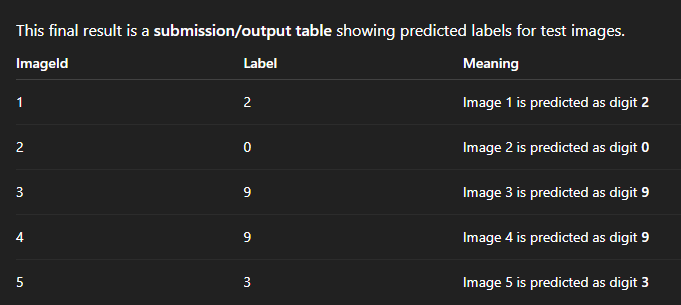

In [50]:
from IPython.display import Image

### for png file
display(Image(filename=r"C:\Users\User\OneDrive\Desktop\\A.png"))

In [52]:
test_pred.to_csv('mnist submission.csv', index = False)

In [ ]:
index = False 
# Prevents row numbers/index values from being written into the CSV file.

test_pred.to_csv('mnist submission.csv', index = False)
# It saves the test_pred results into a CSV file named mnist submission.csv

test_pred 
# A Pandas DataFrame containing prediction results.

# DEPLOYMENT — SAVE FINAL KERAS MODEL AS model.pkl

The original notebook code above is preserved unchanged. This deployment section uses the final trained `model4` model and saves the trained Keras Functional API model as `model.pkl` for Streamlit deployment.

**Recruiter test examples:** upload a 28×28 handwritten digit image or use the built-in sample digit buttons in the Streamlit app. Pixel values are converted to grayscale and scaled to 0–1, matching the notebook preprocessing.

In [ ]:
# Save the FINAL trained model4 without changing the original training code.
import pickle
from pathlib import Path

deployment_model = model4
model_output_path = Path("model.pkl")

with open(model_output_path, "wb") as model_file:
    pickle.dump(deployment_model, model_file)

print("model.pkl saved successfully:")
print(model_output_path.resolve())
print("Model type:", type(deployment_model).__name__)


In [ ]:
# Verify that model.pkl contains a usable Keras model.
with open("model.pkl", "rb") as model_file:
    loaded_deployment_model = pickle.load(model_file)

print("Loaded model type:", type(loaded_deployment_model).__name__)
print("Input shape:", loaded_deployment_model.input_shape)
print("Output shape:", loaded_deployment_model.output_shape)
print("predict() available:", hasattr(loaded_deployment_model, "predict"))


## Recruiter-friendly sample input examples

The deployed app includes built-in sample handwritten digits, so a recruiter can test predictions without the original `train.csv` or `test.csv` files. Manual upload accepts common image formats such as PNG and JPG. Recommended input: one centered handwritten digit on a simple background.

In [ ]:
# Example deployment input using the already-prepared X_test array.
sample_input = X_test[:1].reshape(1, 784)
sample_prediction = model4.predict(sample_input, verbose=0)
print("Sample predicted digit:", int(np.argmax(sample_prediction[0])))
print("Sample confidence:", float(np.max(sample_prediction[0])))
